In [1]:
import numpy as np  # math library
import pandas as pd  # Library to handle databases
import matplotlib.pyplot as plt  # Graphic library
from scipy import stats  # stat library
import statsmodels.api as sm  # statistic modelling library

## Gaussian confidence interval

In the first part of this practical session, we study a real dataset that contains features recorded by 237 Statistics students at the University of Adelaide. In particular, we are interested in the span (distance from tip of thumb to tip of little finger of spread hand) of writing hand, in centimetres. In the dataset this is called `Wr.Hnd`.

In [2]:
df = sm.datasets.get_rdataset("survey", "MASS").data
Wr_hand = np.array(df['Wr.Hnd'])
# span (distance from tip of thumb to tip of little finger of spread hand) of writing hand, in centimetres.
# From 237 Statistics I students at the University of Adelaide.
Wr_hand = Wr_hand[np.isfinite(Wr_hand)]  # remove any missing data (represented by NaN in python, not a number)

In [3]:
print(Wr_hand)
data = pd.DataFrame(Wr_hand)
data.describe()

[18.5 19.5 18.  18.8 20.  18.  17.7 17.  20.  18.5 17.  21.  16.  19.5
 16.  17.5 18.  19.4 20.5 21.  21.5 20.1 18.5 21.5 17.  18.5 21.  20.8
 17.8 19.5 18.5 18.8 17.1 20.1 18.  22.2 16.  19.4 22.  19.  17.5 17.8
 20.1 13.  17.  23.2 22.5 18.  18.  22.  20.5 17.  20.5 22.5 18.5 15.5
 19.5 19.5 20.6 22.8 18.5 19.6 18.7 17.3 19.5 19.  18.5 19.  21.  18.
 19.4 17.  16.5 15.6 17.5 17.  18.6 18.3 20.  19.5 19.2 17.5 17.  23.
 17.7 18.2 18.3 18.  18.  20.5 17.5 18.2 18.2 21.3 19.  20.  17.5 19.5
 19.4 21.9 18.9 16.  17.5 17.5 19.5 16.2 17.  17.5 19.7 18.5 19.2 17.2
 20.5 16.  16.9 17.  23.  18.5 21.  20.  22.5 18.5 19.8 18.5 19.3 16.
 18.8 17.5 16.4 22.  19.  18.9 15.4 17.9 23.1 19.8 22.  20.  19.5 18.
 18.3 19.  21.4 20.  18.5 22.5 19.5 18.  18.  21.8 13.  16.3 21.5 18.9
 20.5 14.  18.9 20.  18.5 17.5 18.1 20.2 16.5 19.1 17.6 19.5 16.5 19.
 19.  16.5 20.5 15.5 18.  17.5 19.  20.5 16.7 20.5 17.  19.  14.  17.5
 18.5 18.  20.5 17.  18.5 18.  18.5 20.  22.  17.9 17.6 16.7 17.  15.
 16.  19.1 1

,0
count,236.000000
mean,18.669068
std,1.878981
min,13.000000
25%,17.500000
50%,18.500000
75%,19.800000
max,23.200000


### Question 1

Plot an histogram of the data and verify that the normal distribution can be proposed to model this dataset by displaying the theoretical density.

(array([0.02492522, 0.        , 0.02492522, 0.        , 0.        ,
        0.01246261, 0.        , 0.04985045, 0.0997009 , 0.04985045,
        0.08723829, 0.21186441, 0.03738784, 0.36141575, 0.28664008,
        0.0997009 , 0.29910269, 0.27417747, 0.08723829, 0.18693918,
        0.18693918, 0.01246261, 0.16201396, 0.08723829, 0.02492522,
        0.04985045, 0.07477567, 0.06231306, 0.01246261, 0.07477567]),
 array([13.  , 13.34, 13.68, 14.02, 14.36, 14.7 , 15.04, 15.38, 15.72,
        16.06, 16.4 , 16.74, 17.08, 17.42, 17.76, 18.1 , 18.44, 18.78,
        19.12, 19.46, 19.8 , 20.14, 20.48, 20.82, 21.16, 21.5 , 21.84,
        22.18, 22.52, 22.86, 23.2 ]),
 <BarContainer object of 30 artists>)

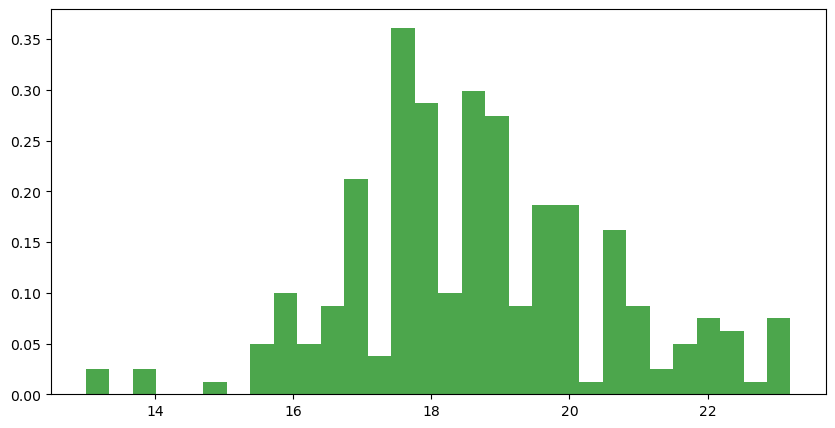

In [4]:
# TODO: Create a histogram of Wr_hand
# Hint: Use plt.hist()
plt.figure(figsize=(10, 5))
plt.hist(Wr_hand, bins=30, density=True, alpha=0.7, color='g')

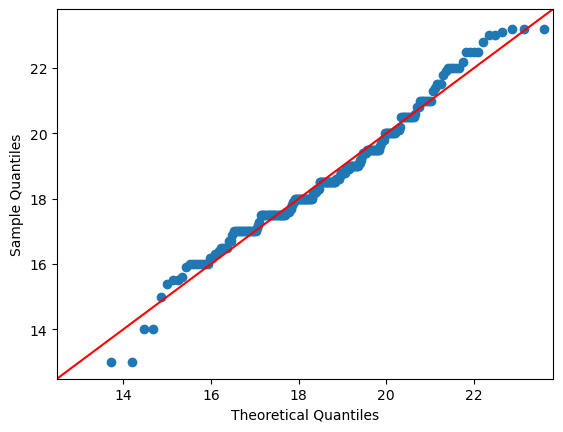

In [10]:
# TODO: Create a Q-Q plot to verify normality
# Hint: Use sm.qqplot() with appropriate parameters
# Remember to specify loc (mean) and scale (std) parameters

# Q-Q plot
_mean = Wr_hand.mean()
_std = Wr_hand.std()

sm.qqplot(Wr_hand,dist=stats.norm,loc=_mean,scale=_std,line='45')
plt.show()

### Question 2
Suppose that the observations in `Wr_hand` are the realizations of random variables $X_1,\dots,X_n$ that are i.i.d variables from $\mathcal{N}(\mu,\sigma^2)$ with unknown parameters $\mu\in\mathbb{R}$ and $\sigma^2>0$.

We are interested in knowing the mean span of writing hand, perhaps to design a splint or some glove. Compute a $95\%$ symmetric confidence interval of $\mu$ (here $\sigma^2$ is unknown).


We have that standardized empirical mean follows a student distribution:
$$ \sqrt{n}\frac{\overline{X}-\mu}{\widehat \sigma}\sim \mathcal{T}(n-1)$$
Then,
\begin{align*}
\mathbb{P}\left( q_{\alpha/2}<\sqrt{n}\frac{\overline{X}-\mu}{\widehat \sigma}<q_{1-\alpha/2}\right)&=\alpha\\
&= \mathbb{P}\left( -q_{1-\alpha/2}<\sqrt{n}\frac{\overline{X}-\mu}{\widehat \sigma}<q_{1-\alpha/2}\right)
\end{align*}
where $q_\alpha$ is a quantile of student distribution of parameter $n-1$.

Simplify by determining the value $a$ allowing to write
\begin{align*}
\mathbb{P}\left( \overline{X}-a < \mu < \overline{X} + a\right)=\alpha
\end{align*}

In [11]:
# TODO: Compute the 95% confidence interval for mu using Student's t-distribution

n = len(Wr_hand)
# TODO: Compute sample mean
mu_hat = _mean
# TODO: Compute sample standard deviation (use ddof=1)
sigma_hat = np.std(Wr_hand,ddof=1)

# TODO: Compute standard error of the mean
n_sqrt = np.sqrt(n)
se_hat = sigma_hat / n_sqrt

# TODO: Determine alpha for 95% CI
alpha = 0.05

# TODO: Find the critical t-value using stats.t.ppf()
t_crit = stats.t.ppf(1-alpha/2,n-1)

# TODO: Compute the margin of error 'a'
a = t_crit * se_hat

# TODO: Compute the confidence interval
conf_int = (mu_hat -a,mu_hat +a)

In [12]:
print(mu_hat,sigma_hat,se_hat,t_crit,a,conf_int)

18.669067796610168 1.8789813842059668 0.12231127008150793 1.970110062267077 0.24096666391624486 (18.428101132693925, 18.91003446052641)


In [13]:
# Display the result
print("The mean span of writing hand is %.2Fcm with 0.95 confidence interval of [%.2F, %.2F]" % (
    mu_hat, conf_int[0], conf_int[1]))

The mean span of writing hand is 18.67cm with 0.95 confidence interval of [18.43, 18.91]


### Question 3

Now we are interested in knowing the variance of the span of writing hand. Compute a $95\%$ confidence interval of $\sigma^2$ (here $\mu$ is unknown).

We have that the standardized empirical variance follows a chi-squared distribution:
$$\frac{1}{\sigma^2}\sum_{i=1}^n (X_i-\overline{X})^2=\frac{(n-1)\widehat{\sigma}^2}{\sigma^2} \sim \chi^2(n-1) $$

Then, we have that
$$\widehat{\sigma}^2=\frac{1}{n-1}\sum_{i=1}^n (X_i-\overline{X})^2$$
and
\begin{align*}
\mathbb{P}\left( q_{\alpha/2}<\frac{(n-1)\widehat{\sigma}^2}{\sigma^2}<q_{1-\alpha/2}\right)&=\alpha\\
&= \mathbb{P}\left( \frac{(n-1)\widehat{\sigma}^2}{q_{1-\alpha/2}}<\sigma^2<\frac{(n-1)\widehat{\sigma}^2}{q_{\alpha/2}}\right)
\end{align*}

In [16]:
# TODO: Compute the 95% confidence interval for sigma^2 using chi-squared distribution
# Hint: Use stats.chi2.ppf() for quantiles

law = stats.chi2
 # TODO: Compute CI using the formula from the theory ab
q_lower = law.ppf(alpha/2, n-1)      
q_upper = law.ppf(1 - alpha/2, n-1)  
conf_int = ((n-1) * sigma_hat / q_upper, (n-1) * sigma_hat / q_lower)

In [17]:
print("The variance of the span of writing hand is %.2F with 0.95 confidence interval of [%.2F, %.2F]." % (
    sigma_hat ** 2, conf_int[0], conf_int[1]))
print("Hence, the std of the span of writing hand is %.2F with 0.95 confidence interval of [%.2F, %.2F]." % (
    sigma_hat, np.sqrt(conf_int[0]), np.sqrt(conf_int[1])))

The variance of the span of writing hand is 3.53 with 0.95 confidence interval of [1.58, 2.27].
Hence, the std of the span of writing hand is 1.88 with 0.95 confidence interval of [1.26, 1.51].


## Illustration of CLT on exponential random variables

### Question 4

In this question, we do $T=1000$ experiments, in each experiment we begin by sampling according to an exponential of parameter $\mu = 1$ with sample size $n=5$, then we compute the empirical mean of this sample that we stock them in an array `means`.
Finally, we represent the sampling law of the means by an histogram.

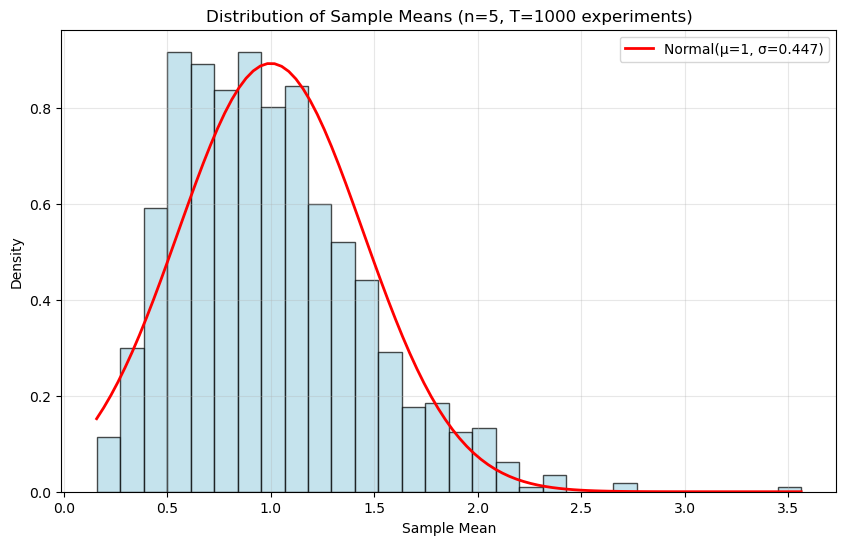

Empirical mean of means: 0.9898
Theoretical mean: 1.0000
Empirical std of means: 0.4454
Theoretical std: 0.4472


In [18]:
T = 1000
n = 5
np.random.seed(42)
means = []

# Loop T times, each time:
for f in range(T):
    # Generate sample from exponential distribution with rate=1 (mean=1)
    sample = np.random.exponential(scale=1, size=n)  # scale=1/rate, so scale=1 for rate=1
    # Compute the mean of the sample
    sample_mean = np.mean(sample)
    # Append to the means list
    means.append(sample_mean)

# Convert to numpy array for easier manipulation
means = np.array(means)

# Plot histogram of means
plt.figure(figsize=(10, 6))
plt.hist(means, bins=30, density=True, alpha=0.7, color='lightblue', edgecolor='black')

# Overlay theoretical normal distribution (CLT approximation)
theoretical_mean = 1  # For exponential(1), E[X] = 1
theoretical_var = 1/n  # Var(X̄) = Var(X)/n = 1/n for exponential(1)
theoretical_std = np.sqrt(theoretical_var)

x = np.linspace(means.min(), means.max(), 100)
theoretical_pdf = stats.norm.pdf(x, theoretical_mean, theoretical_std)
plt.plot(x, theoretical_pdf, 'r-', linewidth=2, 
         label=f'Normal(μ={theoretical_mean}, σ={theoretical_std:.3f})')

plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.title(f'Distribution of Sample Means (n={n}, T={T} experiments)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Empirical mean of means: {np.mean(means):.4f}")
print(f"Theoretical mean: {theoretical_mean:.4f}")
print(f"Empirical std of means: {np.std(means, ddof=1):.4f}")
print(f"Theoretical std: {theoretical_std:.4f}")

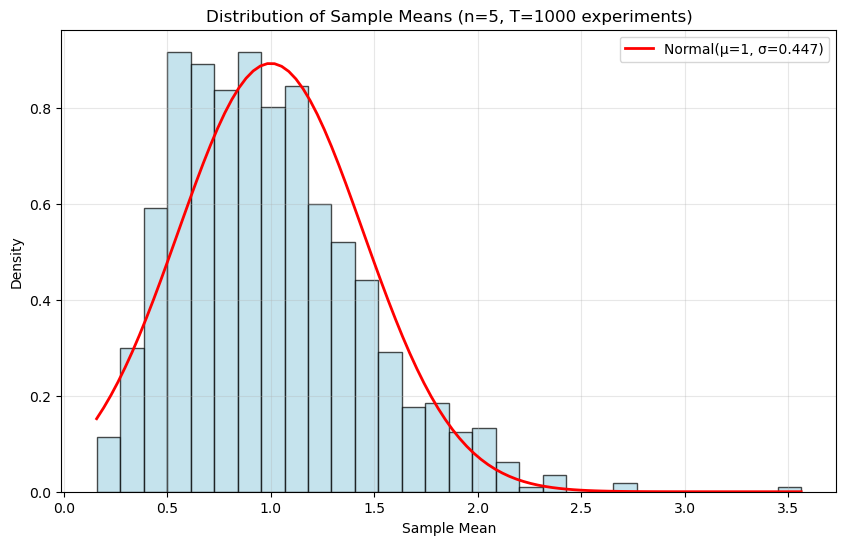

In [20]:
# TODO: Perform T=1000 experiments
T = 1000
n = 5
np.random.seed(42)
means = []

# TODO: Loop T times, each time:
#   1. Generate a sample from exponential distribution (use np.random.exponential)
#   2. Compute the mean of the sample
#   3. Append to the means list

for f in range(T):
    sample = np.random.exponential(scale=1, size=n)
    sample_mean = np.mean(sample)
    means.append(sample_mean)
    
means = np.array(means)
# TODO: Plot histogram of means
plt.figure(figsize=(10, 6))
plt.hist(means, bins=30, density=True, alpha=0.7, color='lightblue', edgecolor='black')
theoretical_mean = 1  
theoretical_var = 1/n 
theoretical_std = np.sqrt(theoretical_var)

x = np.linspace(means.min(), means.max(), 100)
theoretical_pdf = stats.norm.pdf(x, theoretical_mean, theoretical_std)
plt.plot(x, theoretical_pdf, 'r-', linewidth=2, 
         label=f'Normal(μ={theoretical_mean}, σ={theoretical_std:.3f})')

plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.title(f'Distribution of Sample Means (n={n}, T={T} experiments)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Question 5

The Central Limit Theorem (CLT) gives the approximate Gaussian distribution of the sample mean, whatever the generative law of the sample. We apply it on an exponential sample.

**Recall:** By the CLT, we have
$$\sqrt{n}\frac{\bar{X}_n - \mathbb{E}[X]}{\sqrt{\mathrm{Var}(X)}} \xrightarrow{d} \mathcal{N}(0,1)$$
where $\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i$ is the sample mean.

Histograms are not the right tool to visualize complex behavior of a density; instead we will look at the CDF.

**Tasks:**
1. If the empirical means are stored in `means`, construct a vector `renormalized_means` that contains the values of 
   $$\sqrt{n}\frac{\bar{X}_n - \mathbb{E}[X]}{\sqrt{\mathrm{Var}(X)}}$$
   
2. Plot the empirical CDF of `renormalized_means` and the theoretical CDF of the standard normal distribution $\mathcal{N}(0,1)$.

3. Repeat with $n=100$ and plot the associated empirical CDF on the same figure.

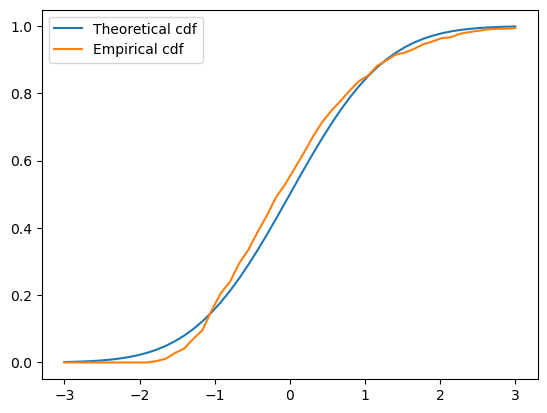

In [22]:
# Helper function for empirical CDF
def ecdf(x, sample):
    return np.mean(sample <= x)

# TODO: For exponential(1), E[X] = 1 and Var(X) = 1
# TODO: Renormalize the means using the CLT formula
means = np.array(means)
xplot = np.linspace(-3, 3)

# TODO: Plot theoretical CDF of N(0,1)
plt.plot(xplot, stats.norm().cdf(xplot), label='Theoretical cdf')

# TODO: Compute renormalized_means and plot empirical CDF
renormalized_means = np.sqrt(n) * (means - E_X) / np.sqrt(Var_X)

# TODO: Plot empirical CDF
plt.plot(xplot, [ecdf(x, renormalized_means) for x in xplot], label='Empirical cdf')
plt.legend()

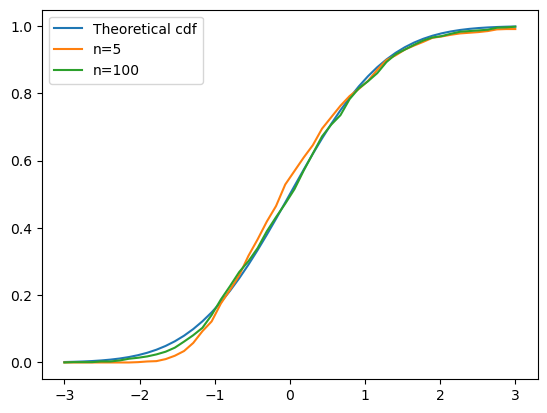

In [25]:
# TODO: Repeat for n=5 and n=100, compare on the same plot
xplot = np.linspace(-3, 3)
plt.plot(xplot, stats.norm().cdf(xplot), label='Theoretical cdf')

for n in [5, 100]:
    means = []
    # TODO: Generate T samples for each n
    for f in range(T):
        sample = np.random.exponential(scale=1, size=n)
        sample_mean = np.mean(sample)
        means.append(sample_mean)
    means = np.array(means)
    # TODO: Renormalize and plot
    renormalized_means = np.sqrt(n) * (means - E_X) / np.sqrt(Var_X)
    plt.plot(xplot, [ecdf(x, renormalized_means) for x in xplot], label='n=' + str(n))

plt.legend()

## Confidence interval based on the CLT

In this final part, we study the `quine` dataset from Walgett, New South Wales, Australia. This dataset contains 146 observations of children classified by:
- **Eth**: Ethnicity (Aboriginal or Non-Aboriginal)
- **Sex**: Gender (Male or Female)  
- **Age**: Age group (Primary or Secondary)
- **Lrn**: Learner status (Average or Slow learner)
- **Days**: Number of days absent from school in a particular school year

The variable of interest is `Days`, the number of absence days, which ranges from 0 to 81 with a mean of approximately 16.5 days.

In [26]:
df = sm.datasets.get_rdataset("quine", "MASS").data

In [27]:
df.head()

,Eth,Sex,Age,Lrn,Days
0,A,M,F0,SL,2
1,A,M,F0,SL,11
2,A,M,F0,SL,14
3,A,M,F0,AL,5
4,A,M,F0,AL,5


The distribution of absence days is right-skewed with a median of 11 days. We will model the `Days` variable using an **exponential distribution**.

### Question 6
Compute a $95\%$ confidence interval of the mean $\mu$ of the distribution.

In [30]:
# TODO: Use CLT to compute 95% CI for the mean
# Hint: For exponential, we can use CLT with normal approximation
# For exponential distribution, SE = mu_hat / sqrt(n)

# mu_hat = # TODO: Compute sample mean of 'Days'
days_data = df['Days'].values
mu_hat = np.mean(days_data)
law = stats.norm
# alpha = # TODO: Set alpha for 95% CI
alpha = 0.05
n = len(days_data) 

# TODO: Compute confidence interval
# Hint: CI = (mu_hat - z * SE, mu_hat + z * SE)
se = mu_hat / np.sqrt(n)

# Use normal approximation (CLT)
z = stats.norm.ppf(1 - alpha/2)

# Compute confidence interval
margin_error = z * se
conf_int = (mu_hat - margin_error, mu_hat + margin_error)

In [31]:
print("The mean duration of absence for the children is %.2F days with 0.95 confidence interval of [%.2F, %.2F]" % (
    mu_hat, conf_int[0], conf_int[1]))

The mean duration of absence for the children is 16.46 days with 0.95 confidence interval of [13.79, 19.13]


### Question 7
Suppose that we collect a new dataset from the same population with the same features observed on other children, and that we construct a confidence interval with this data set using the same method. What is the probability that the confidence interval contains the true value of $\mu$ ? Warning: the confidence interval is random and $\mu$ is fixed.

## Real-World Application: NYC Taxi Trip Duration Analysis

In this extended section, we analyze a real-world dataset of NYC taxi trip durations. This exercise demonstrates how to apply confidence interval methods to data that requires transformation and careful interpretation.

**Dataset**: NYC Taxi Trip Duration  
**Source**: Synthetic data based on realistic patterns from NYC taxi operations  
**Size**: 15,000 trip records  

**Context**: Understanding trip duration patterns is crucial for:
- Ride-hailing app time estimates
- Driver earnings projections
- Urban traffic planning
- Customer experience optimization

### Question 8: Data Loading and Initial Exploration

Load the NYC taxi dataset and perform initial exploratory analysis:
1. Load the data from `shared/data/nyc-taxi/nyc_taxi_trip_duration.csv`
2. Display the first few rows and basic information
3. Create a histogram of trip duration (in minutes)
4. Compute basic summary statistics

In [33]:
# TODO: Load the NYC taxi data
taxi_df = # Load from '../../shared/data/nyc-taxi/nyc_taxi_trip_duration.csv'

# TODO: Display basic information
print("Dataset shape:", taxi_df.shape)
print("\nFirst few rows:")
# Display first few rows

# TODO: Convert trip duration to minutes for easier interpretation
taxi_df['trip_duration_min'] = # Convert from seconds to minutes

# TODO: Summary statistics
print("\nTrip Duration Summary (in minutes):")
# Display summary statistics

# TODO: Create visualizations
plt.figure(figsize=(12, 4))

# Histogram
plt.subplot(1, 2, 1)
# TODO: Create histogram with bins=50
# TODO: Add vertical lines for mean and median
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of NYC Taxi Trip Durations')
plt.legend()

# Boxplot
plt.subplot(1, 2, 2)
# TODO: Create boxplot
plt.ylabel('Trip Duration (minutes)')
plt.title('Boxplot of Trip Durations')

plt.tight_layout()
plt.show()

# TODO: Print observation about skewness

SyntaxError: invalid syntax (2234608395.py, line 2)

### Question 9: Normality Assessment and Transformation

The trip duration distribution is clearly right-skewed. A common approach for positive right-skewed data is to apply a **log-transformation**.

**Tasks:**
1. Create a QQ-plot comparing the raw trip duration to a normal distribution
2. Apply a log-transformation: `log_duration = log(trip_duration)`
3. Create a QQ-plot for the log-transformed data
4. Compare the two plots and conclude which distribution is more appropriate

In [ ]:
# TODO: Apply log transformation first
taxi_df['log_duration'] = # Hint: Use np.log() on 'trip_duration'

plt.figure(figsize=(14, 5))

# QQ-plot for raw data
ax1 = plt.subplot(1, 3, 1)
# TODO: Create QQ-plot for raw trip_duration_min
# Hint: Use sm.qqplot() with ax=ax1
plt.title('QQ-Plot: Raw Trip Duration')

# QQ-plot for log-transformed data
ax2 = plt.subplot(1, 3, 2)
# TODO: Create QQ-plot for log_duration
plt.title('QQ-Plot: Log-Transformed Duration')

# Histogram of log-transformed data
plt.subplot(1, 3, 3)
# TODO: Create histogram of log_duration with density=True
plt.xlabel('Log(Trip Duration)')
plt.ylabel('Density')
plt.title('Distribution of Log-Transformed Duration')

# TODO: Overlay normal distribution fit
# Hint: Use stats.norm.pdf() with mean and std of log_duration
x = np.linspace(taxi_df['log_duration'].min(), taxi_df['log_duration'].max(), 100)
# Plot normal PDF
plt.legend()

plt.tight_layout()
plt.show()

# TODO: Print conclusion

### Question 10: Confidence Interval for Mean Trip Duration Using CLT

Now we'll construct a confidence interval for the **mean log-duration** using the CLT, then transform it back to the original scale.

**Background**: When data follows a log-normal distribution $X \sim \text{LogNormal}(\mu, \sigma^2)$, then $\log(X) \sim \mathcal{N}(\mu, \sigma^2)$.

**Tasks:**
1. Estimate $\mu$ and $\sigma^2$ for the log-transformed data
2. Construct a 95% confidence interval for $\mu$ using the CLT
3. Transform the CI back to the original scale by exponentiating
4. Interpret the result: this gives us a CI for the **geometric mean** of trip duration

In [ ]:
# Sample size
n = len(taxi_df)

# TODO: Estimate parameters for log-duration
mu_log = # Mean of log_duration
sigma_log = # Standard deviation of log_duration (use ddof=1)
se_log = # Standard error

# TODO: 95% confidence interval for mu (log scale)
alpha = 0.05
z_crit = # Critical value for 95% CI
ci_log_lower = # Lower bound on log scale
ci_log_upper = # Upper bound on log scale

print("Log-scale parameters:")
print(f"  μ̂ = {mu_log:.4f}")
print(f"  σ̂ = {sigma_log:.4f}")
print(f"  SE(μ̂) = {se_log:.4f}")
print(f"\n95% CI for μ (log-scale): [{ci_log_lower:.4f}, {ci_log_upper:.4f}]")

# TODO: Transform back to original scale (geometric mean)
# Hint: geometric_mean = exp(mu_log)
geometric_mean =
ci_original_lower =
ci_original_upper =

print(f"\nGeometric mean trip duration: {geometric_mean:.2f} seconds ({geometric_mean/60:.2f} minutes)")
print(f"95% CI for geometric mean: [{ci_original_lower:.2f}, {ci_original_upper:.2f}] seconds")
print(f"                         = [{ci_original_lower/60:.2f}, {ci_original_upper/60:.2f}] minutes")

# TODO: Compare with arithmetic mean
arithmetic_mean = taxi_df['trip_duration'].mean()
print(f"\nComparison:")
print(f"  Arithmetic mean: {arithmetic_mean:.2f} seconds ({arithmetic_mean/60:.2f} minutes)")
print(f"  Geometric mean:  {geometric_mean:.2f} seconds ({geometric_mean/60:.2f} minutes)")
print(f"  Median:          {taxi_df['trip_duration'].median():.2f} seconds ({taxi_df['trip_duration'].median()/60:.2f} minutes)")
print(f"\nNote: For log-normal data, geometric mean < median < arithmetic mean")

### Question 11: Comparing Rush Hour vs Non-Rush Hour Trips

Let's investigate whether rush hour affects trip duration by comparing two groups:
- **Rush hour**: Morning (7-9am) and Evening (5-7pm)
- **Non-rush hour**: All other times

**Tasks:**
1. Separate the data into rush hour and non-rush hour groups
2. For each group, compute the geometric mean and 95% CI
3. Determine if the confidence intervals overlap
4. Interpret the practical significance

In [ ]:
def compute_lognormal_ci(data, alpha=0.05):
    """Compute CI for geometric mean of log-normally distributed data"""
    # TODO: Complete this function
    n = len(data)
    log_data = np.log(data)
    mu_log = # Mean of log data
    sigma_log = # Std of log data (ddof=1)
    se_log = # Standard error

    z_crit = # Critical z-value
    ci_log = # CI on log scale

    geometric_mean = # exp(mu_log)
    ci_original = # Transform CI back to original scale

    return geometric_mean, ci_original, n

# TODO: Separate groups based on is_rush_hour column
rush_hour_data = # Filter for rush hour trips
non_rush_data = # Filter for non-rush hour trips

# TODO: Compute CIs for each group
gm_rush, ci_rush, n_rush = compute_lognormal_ci(rush_hour_data)
gm_non_rush, ci_non_rush, n_non_rush = compute_lognormal_ci(non_rush_data)

# Print results
print("="*70)
print("RUSH HOUR TRIPS")
print("="*70)
print(f"Sample size: {n_rush}")
print(f"Geometric mean: {gm_rush:.2f} seconds ({gm_rush/60:.2f} minutes)")
print(f"95% CI: [{ci_rush[0]:.2f}, {ci_rush[1]:.2f}] seconds")
print(f"      = [{ci_rush[0]/60:.2f}, {ci_rush[1]/60:.2f}] minutes")

print("\n" + "="*70)
print("NON-RUSH HOUR TRIPS")
print("="*70)
print(f"Sample size: {n_non_rush}")
print(f"Geometric mean: {gm_non_rush:.2f} seconds ({gm_non_rush/60:.2f} minutes)")
print(f"95% CI: [{ci_non_rush[0]:.2f}, {ci_non_rush[1]:.2f}] seconds")
print(f"      = [{ci_non_rush[0]/60:.2f}, {ci_non_rush[1]/60:.2f}] minutes")

print("\n" + "="*70)
print("COMPARISON")
print("="*70)
percent_diff = ((gm_rush - gm_non_rush) / gm_non_rush) * 100
print(f"Difference in geometric means: {gm_rush - gm_non_rush:.2f} seconds ({percent_diff:.1f}% longer in rush hour)")

# TODO: Check if CIs overlap
if ci_rush[0] > ci_non_rush[1] or ci_non_rush[0] > ci_rush[1]:
    print("Confidence intervals DO NOT overlap → statistically significant difference")
else:
    print("Confidence intervals overlap → difference may not be statistically significant")

# TODO: Create visualizations comparing the groups
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# TODO: Create error bar plot showing geometric means with CIs
# Hint: Use plt.errorbar()
plt.xticks([1, 2], ['Non-Rush Hour', 'Rush Hour'])
plt.ylabel('Trip Duration (minutes)')
plt.title('Geometric Mean Trip Duration with 95% CI')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
# TODO: Create overlapping histograms
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Density')
plt.title('Distribution Comparison')
plt.legend()

plt.tight_layout()
plt.show()

### Question 12: Practical Interpretation and Recommendations

Based on your analysis, answer the following questions:

1. **Why is the geometric mean more appropriate than the arithmetic mean for log-normal data?**

2. **What would you tell a ride-hailing company about expected trip times?**
   - What's a reasonable estimate to show customers?
   - Should they adjust estimates during rush hour?

3. **Sample size considerations**: 
   - How would the confidence interval width change with 5,000 trips vs 15,000 trips?
   - Use the formula for CI width to explain.

4. **Limitations of this analysis**:
   - What factors are we not accounting for?
   - What additional data would improve the analysis?

In [ ]:
# TODO: Write your answers and supporting analysis here

# Question 1: Geometric mean vs arithmetic mean
# Your answer:

# Question 2: Recommendations for ride-hailing company
# Your answer:

# Question 3: Sample size impact on CI width
# TODO: Calculate CI widths for different sample sizes
# Hint: CI width ∝ 1/√n
sample_sizes = [5000, 15000, 50000]
# Your code here

# Question 4: Limitations and improvements
# Your answer:

### Bonus: Sample Size Effect Visualization

Visualize how sample size affects confidence interval width.

In [ ]:
# TODO: Bonus visualization - how sample size affects CI width
sample_sizes = [1000, 2000, 5000, 10000, 15000, 20000, 30000]
ci_widths = []

for n_sample in sample_sizes:
    # TODO: Sample from data (with replacement if n_sample > data size)
    # TODO: Compute CI using compute_lognormal_ci()
    # TODO: Calculate width in minutes and append to ci_widths
    pass

# TODO: Create plot showing sample size vs CI width
plt.figure(figsize=(10, 5))
# Your plotting code here
plt.xlabel('Sample Size (n)')
plt.ylabel('95% CI Width (minutes)')
plt.title('How Sample Size Affects Confidence Interval Precision')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Key insight: Doubling sample size reduces CI width by factor of √2 ≈ 1.41")